# Problem Statement :
To analyze the EazyDiner restaurant dataset and identify the factors affecting restaurant ratings, pricing, discounts, cuisine popularity, and regional distribution. The goal is to uncover meaningful business insights through Exploratory Data Analysis (EDA) that support better decision-making for both restaurants and customers.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv(r"C:\Users\mones\Innomatics\EDA Projects\eazydiner_cleaned_data.csv")
df.head()

,Restaurants_Name,Cuisine,area,region,Discount,cost_of_two,ratings
0,Hamza Express - Since 1918,Multicuisine,Shivajinagar,Central Bengaluru,35,650,4.0
1,Hamza Express - Since 1918,Multicuisine,Shivajinagar,Central Bengaluru,35,650,4.0
2,Savera Lassi Shop,"Beverages, Ice Cream",Shivajinagar,Central Bengaluru,35,2000,4.7
3,Savera Lassi Shop,"Beverages, Ice Cream",Shivajinagar,Central Bengaluru,35,2000,4.7
4,My Breakfast,Multicuisine,Shivajinagar,Central Bengaluru,35,2000,4.0


In [4]:
df.shape

(2400, 7)

### Observation:
The dataset contain 2400 rows and 7 columns.

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2400 entries, 0 to 2399
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Restaurants_Name  2400 non-null   object 
 1   Cuisine           2398 non-null   object 
 2   area              2212 non-null   object 
 3   region            2212 non-null   object 
 4   Discount          2400 non-null   int64  
 5   cost_of_two       2400 non-null   int64  
 6   ratings           2400 non-null   float64
dtypes: float64(1), int64(2), object(4)
memory usage: 131.4+ KB


In [12]:
df.describe()

,Discount,cost_of_two,ratings
count,1200.000000,1200.000000,1200.000000
mean,33.320833,1853.458333,4.225250
std,7.322630,849.247593,0.626124
min,0.000000,200.000000,1.000000
25%,25.000000,1500.000000,4.000000
50%,35.000000,2000.000000,4.200000
75%,35.000000,2000.000000,4.600000
max,75.000000,9440.000000,5.000000


## Data Cleaning :
1. Missing values
2. Duplicates
3. Outliers
4. Type Casting
5. Noisy or inconsistent data

In [6]:
df.isnull().sum()

Restaurants_Name      0
Cuisine               2
area                188
region              188
Discount              0
cost_of_two           0
ratings               0
dtype: int64

In [7]:
round((df.isnull().sum()/df.shape[0]) * 100,2)

Restaurants_Name    0.00
Cuisine             0.08
area                7.83
region              7.83
Discount            0.00
cost_of_two         0.00
ratings             0.00
dtype: float64

In [8]:
df.duplicated().sum()

np.int64(1200)

In [9]:
df.drop_duplicates(inplace=True)

In [10]:
df.columns

Index(['Restaurants_Name', 'Cuisine', 'area', 'region', 'Discount',
       'cost_of_two', 'ratings'],
      dtype='object')

## Check Unique Values

In [11]:
df.nunique()

Restaurants_Name    1174
Cuisine              284
area                 237
region                 6
Discount               9
cost_of_two           49
ratings               32
dtype: int64

<Axes: >

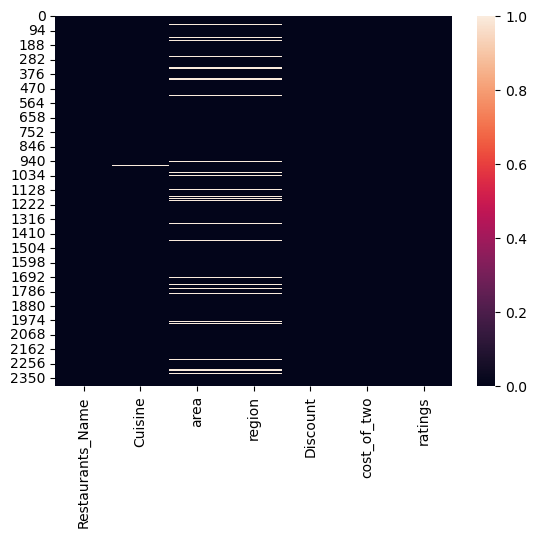

In [13]:
sns.heatmap(df.isnull())

## Handle Missing Values

In [14]:
df["Cuisine"] = df["Cuisine"].fillna(df["Cuisine"].mode()[0])

df["area"] = df["area"].fillna(df["area"].mode()[0])

df["region"] = df["region"].fillna(df["region"].mode()[0])

In [15]:
df.isnull().sum()

Restaurants_Name    0
Cuisine             0
area                0
region              0
Discount            0
cost_of_two         0
ratings             0
dtype: int64

In [16]:
df

,Restaurants_Name,Cuisine,area,region,Discount,cost_of_two,ratings
0,Hamza Express - Since 1918,Multicuisine,Shivajinagar,Central Bengaluru,35,650,4.0
2,Savera Lassi Shop,"Beverages, Ice Cream",Shivajinagar,Central Bengaluru,35,2000,4.7
4,My Breakfast,Multicuisine,Shivajinagar,Central Bengaluru,35,2000,4.0
6,Nawabi Chai,Cafe,Shivajinagar,Central Bengaluru,35,200,4.0
8,Tipsy Cafe,Fast Food,Shivajinagar,Central Bengaluru,35,2000,4.0
...,...,...,...,...,...,...,...
2390,Tango Kitchen & Bar,"Chinese, Indian, Continental",Mahadevapura,Bengaluru,35,1200,4.5
2392,Tiffanys,Multicuisine,Shanti Nagar,Central Bengaluru,25,2000,4.6
2394,The Brew Factory Sahakara Nagar,Multicuisine,Yelahanka,North Bengaluru,25,2500,5.0
2396,Hyderabadi Bawarchi,Biryani,Yelahanka,North Bengaluru,40,2000,1.8


In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1200 entries, 0 to 2398
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Restaurants_Name  1200 non-null   object 
 1   Cuisine           1200 non-null   object 
 2   area              1200 non-null   object 
 3   region            1200 non-null   object 
 4   Discount          1200 non-null   int64  
 5   cost_of_two       1200 non-null   int64  
 6   ratings           1200 non-null   float64
dtypes: float64(1), int64(2), object(4)
memory usage: 75.0+ KB


# Check Outliers

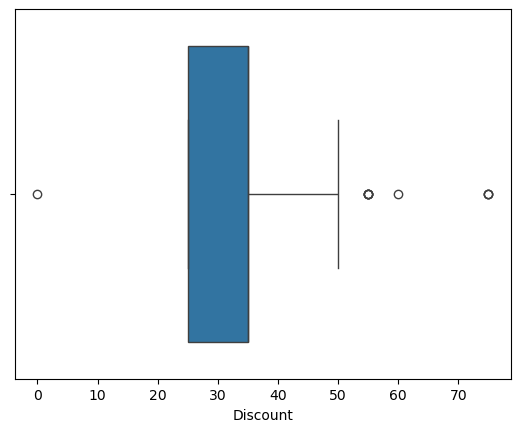

In [18]:
sns.boxplot(x = df['Discount'])
plt.show()

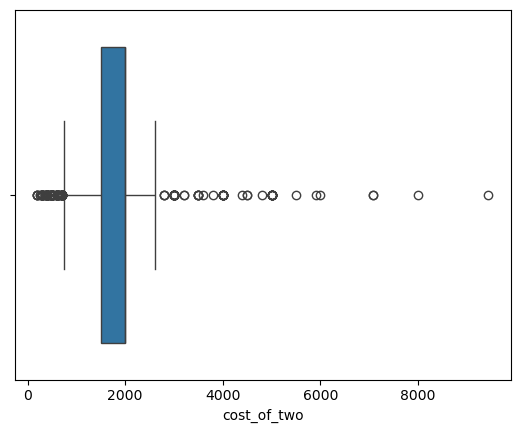

In [19]:
sns.boxplot(x = df['cost_of_two'])
plt.show()

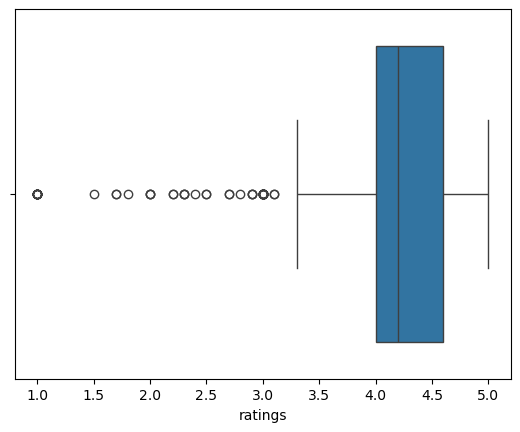

In [20]:
sns.boxplot(x = df['ratings'])
plt.show()

## Handling Outliers

In [21]:
num_cols = ["Discount","cost_of_two","ratings"]

In [22]:
for col in num_cols:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3-Q1

    lower = Q1-1.5*IQR
    upper = Q3+1.5*IQR

    outliers = df[(df[col]<lower)|(df[col]>upper)]
    print(col,len(outliers))

Discount 10
cost_of_two 193
ratings 65


In [23]:
for col in num_cols:

    Q1=df[col].quantile(0.25)
    Q3=df[col].quantile(0.75)

    IQR=Q3-Q1

    lower=Q1-1.5*IQR
    upper=Q3+1.5*IQR

    df[col]=np.where(df[col]>upper,upper,df[col])
    df[col]=np.where(df[col]<lower,lower,df[col])

# Univariate Analysis

## Rating Distribution

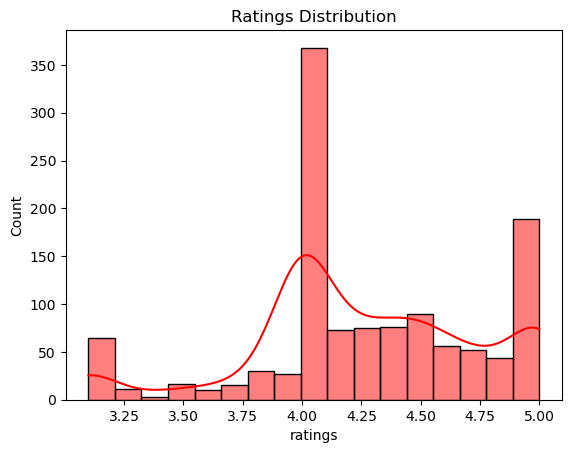

In [44]:
sns.histplot(df["ratings"],kde=True, color = "red")
plt.title("Ratings Distribution")
plt.show()

### Observations :
- Most restaurant ratings are concentrated between 4.0 and 4.5, indicating generally positive customer reviews.
- The distribution is slightly left-skewed, with very few restaurants having low ratings.
- Overall, the platform consists mainly of well-rated restaurants, reflecting good customer satisfaction.

## Top 10 Restaurant Rating 

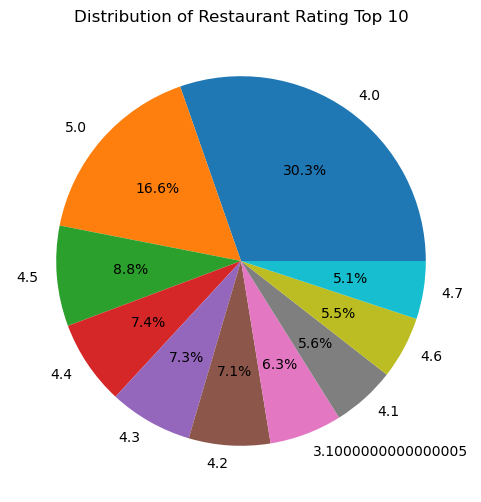

In [73]:
plt.figure(figsize=(6, 6))
# 1.the top 5 most common ratings
counts = df["ratings"].value_counts().head(10)
plt.title("Distribution of Restaurant Rating Top 10")
plt.pie(counts, labels=counts.index, autopct='%1.1f%%')
plt.show()

## Discount Distribution 

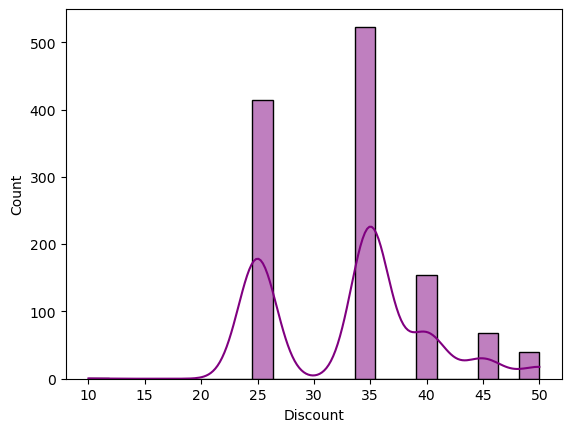

In [71]:
sns.histplot(df["Discount"],kde=True, color = "purple")
plt.show()

### Observations :
- Most restaurants offer low to moderate discounts, while high discounts are offered by only a few restaurants.
- The distribution is right-skewed, indicating that larger discount values are less common.
- Overall, restaurants generally provide moderate promotional offers rather than very high discounts.

## Top 10 Cuisines

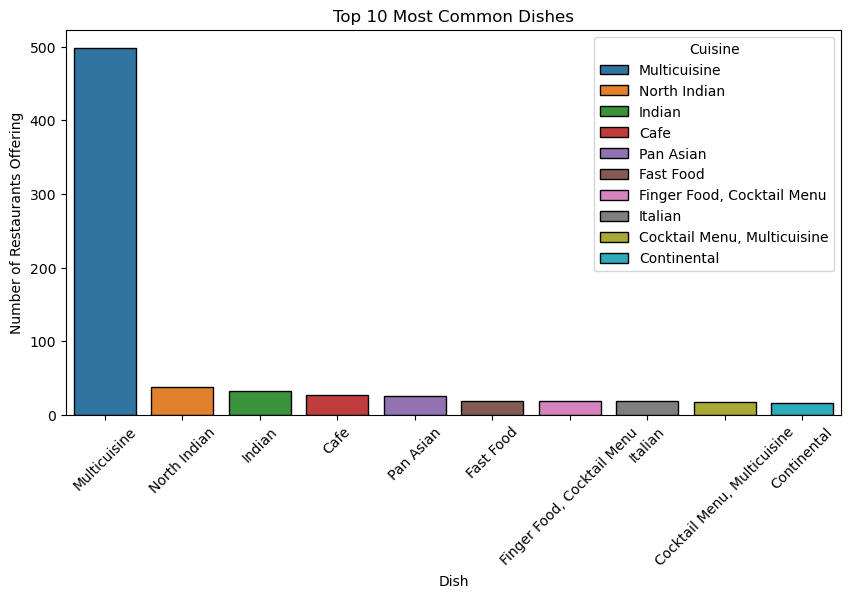

In [79]:
dish_counts = df["Cuisine"].value_counts()

plt.figure(figsize=(10,5))
sns.barplot(x=dish_counts.head(10).index, y=dish_counts.head(10).values, hue =dish_counts.head(10).index, legend = True , edgecolor="black")
plt.title("Top 10 Most Common Dishes")
plt.ylabel("Number of Restaurants Offering")
plt.xlabel("Dish")
plt.xticks(rotation=45)
plt.savefig("Top 10 Most Common Dish.png",dpi = 400, bbox_inches = "tight")
plt.show()

### Observations 
- The bar chart shows the top 10 most popular cuisines based on the number of restaurants listed in the dataset.
- A few cuisines have significantly more restaurants than others, indicating higher popularity and customer demand.
- The dataset is dominated by these cuisines, while other cuisine types have comparatively fewer restaurants.

## Region Distribution

C:\Users\mones\AppData\Local\Temp\ipykernel_17740\2573265166.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df["region"], order=df["region"].value_counts().index, palette = "mako")


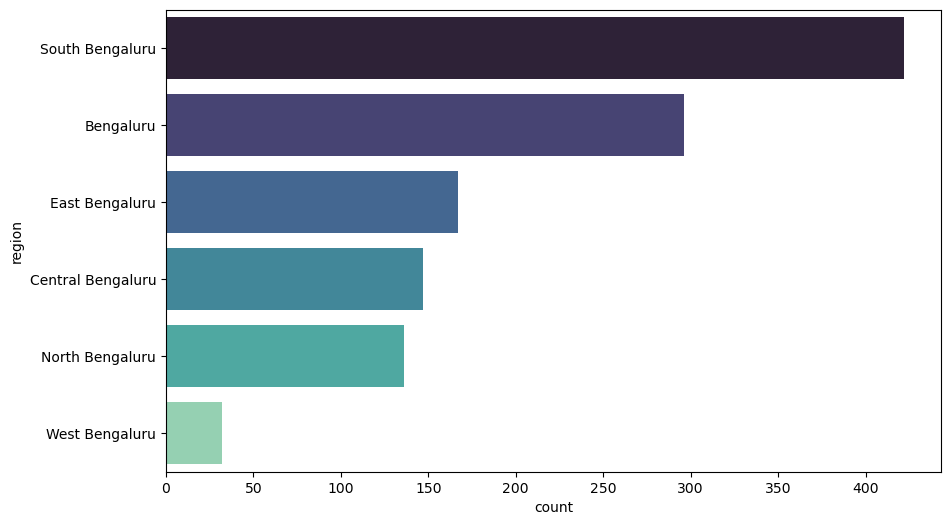

In [74]:
plt.figure(figsize=(10,6))
sns.countplot(y=df["region"], order=df["region"].value_counts().index, palette = "mako")
plt.show()

### Observations :
- The count plot shows that some regions have a much higher number of restaurants than others.
- This indicates an uneven distribution of restaurants, with a few regions dominating the dataset.
- Regions with fewer restaurants may represent lower market presence or customer demand.

# Bivariate Analysis

## Cost vs Rating

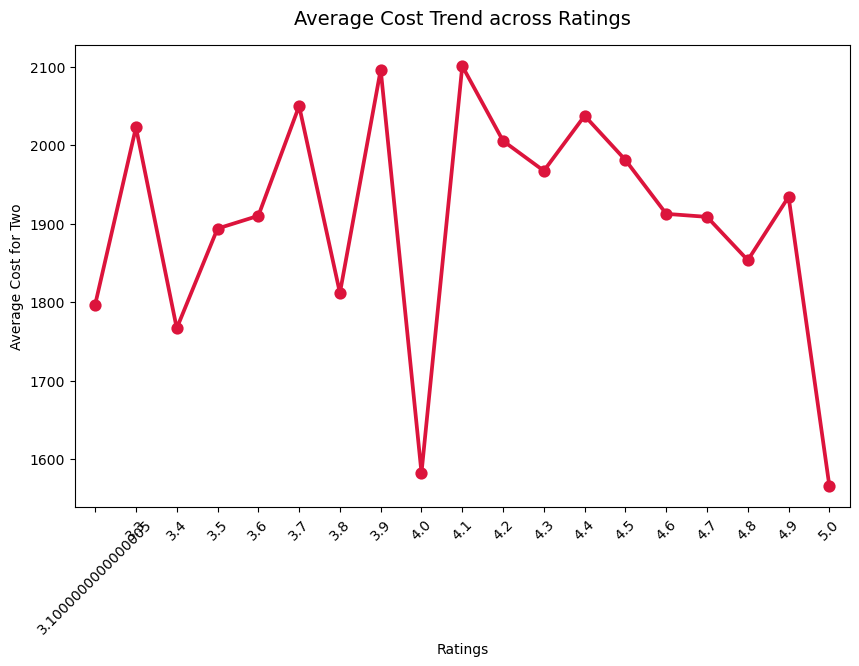

In [75]:
plt.figure(figsize=(10, 6))
sns.pointplot(data=df, x="ratings", y="cost_of_two", color="crimson", errorbar=None)
plt.title("Average Cost Trend across Ratings", fontsize=14, pad=15)
plt.xlabel("Ratings")
plt.ylabel("Average Cost for Two")
plt.xticks(rotation=45)
plt.show()

### Observation :
- The point plot shows how the average cost for two varies across different restaurant ratings.
- The trend indicates that higher-rated restaurants generally have a slightly higher average cost, though the relationship is not very strong.
- Overall, restaurant price alone does not determine customer ratings, as both affordable and expensive restaurants receive good ratings.

## Discount vs Rating

Text(0.5, 1.0, 'Discount across Rating')

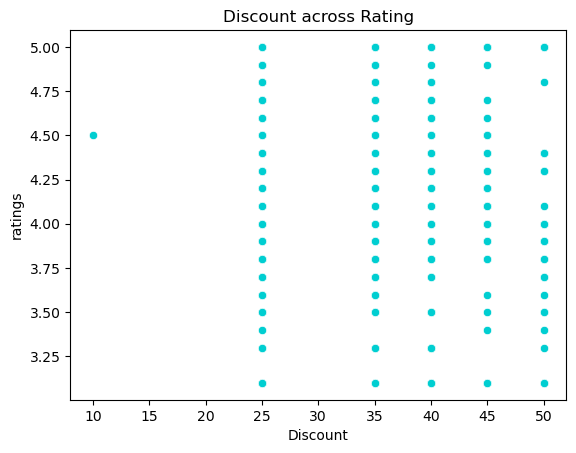

In [59]:
sns.scatterplot(data=df, x="Discount", y="ratings", color="darkturquoise")
plt.title("Discount across Rating")

### Observations :
- The scatter plot shows no strong relationship between discounts and restaurant ratings.
- Restaurants with both high and low discounts receive similar ratings, indicating discounts do not significantly affect customer satisfaction.
- Overall, restaurant ratings appear to depend on factors other than discounts, such as food quality and service.

## Average Rating by Region

C:\Users\mones\AppData\Local\Temp\ipykernel_17740\2939468602.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x="region", y="ratings", palette = "magma")


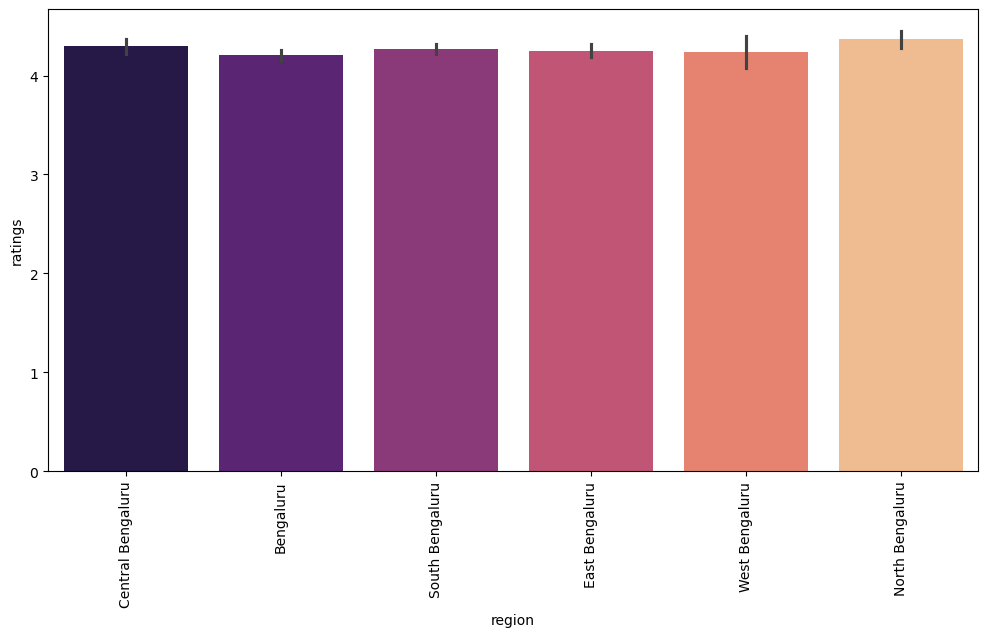

In [30]:
plt.figure(figsize=(12,6))
sns.barplot(data=df, x="region", y="ratings", palette = "magma")
plt.xticks(rotation=90)
plt.show()

### Observations :
- The bar plot compares the average restaurant ratings across different regions.
- Some regions have slightly higher average ratings, indicating better customer satisfaction in those areas.
- Overall, the ratings are fairly consistent across regions, with only minor differences.

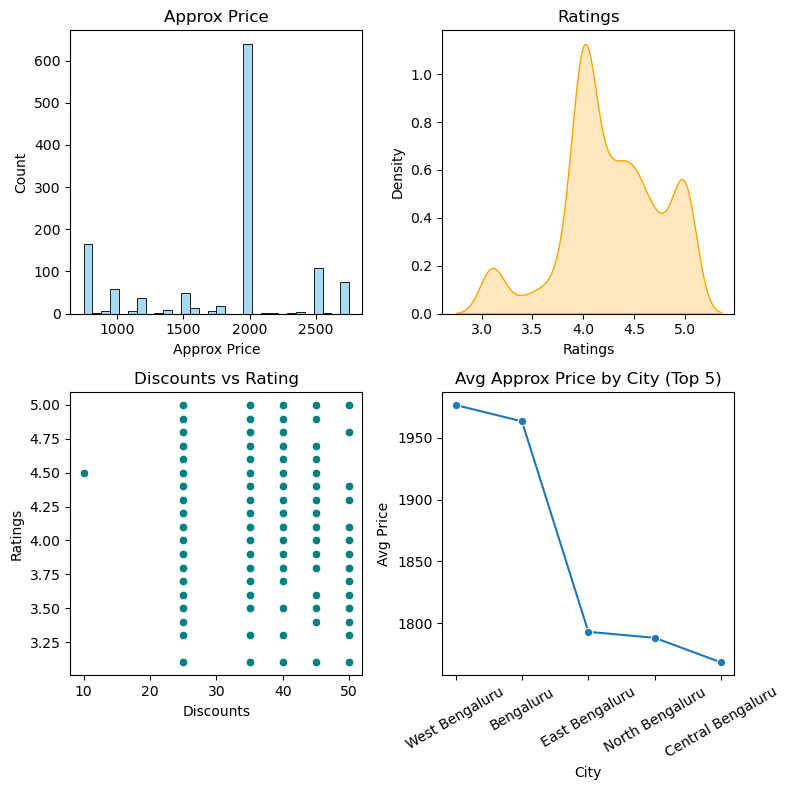

In [31]:
plt.figure(figsize=(8,8))

# Histogram: Approx Price
plt.subplot(2,2,1)
sns.histplot(df["cost_of_two"], bins=30, color="skyblue")
plt.title("Approx Price")
plt.xlabel("Approx Price")
plt.ylabel("Count")

# KDE Plot: Rating
plt.subplot(2,2,2)
sns.kdeplot(df["ratings"], fill=True, color="orange")
plt.title("Ratings")
plt.xlabel("Ratings")
plt.ylabel("Density")

# Scatterplot: Discounts vs Rating
plt.subplot(2,2,3)
sns.scatterplot(x="Discount", y="ratings", data=df, color="teal")
plt.title("Discounts vs Rating")
plt.xlabel("Discounts")
plt.ylabel("Ratings")

# Line Plot: Avg Price by City (Top 5)
plt.subplot(2,2,4)
avg_price = df.groupby("region")["cost_of_two"].mean().sort_values(ascending=False).head(5)
sns.lineplot(x=avg_price.index, y=avg_price.values, marker="o")
plt.title("Avg Approx Price by City (Top 5)")
plt.xlabel("City")
plt.ylabel("Avg Price")
plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

# Multivariate Analysis

## Correlation heatmap

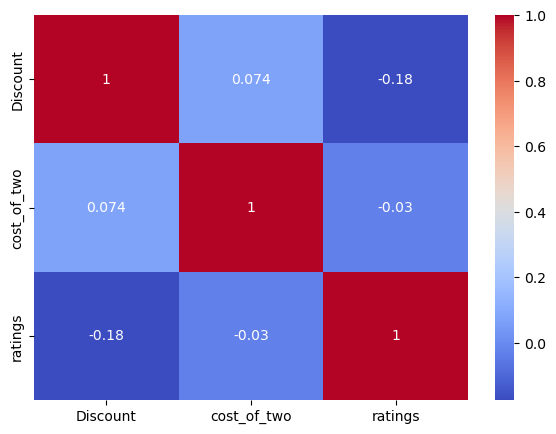

In [76]:
plt.figure(figsize=(7,5))
sns.heatmap(df[num_cols].corr(), annot=True, cmap="coolwarm")
plt.show()

### Observations :
- The correlation heatmap shows that most numerical features have weak correlations with each other.
- Ratings, discounts, and cost of two are largely independent, indicating no strong linear relationship.
- Overall, no pair of numerical variables exhibits a strong positive or negative correlation in the dataset

## Pair Plot

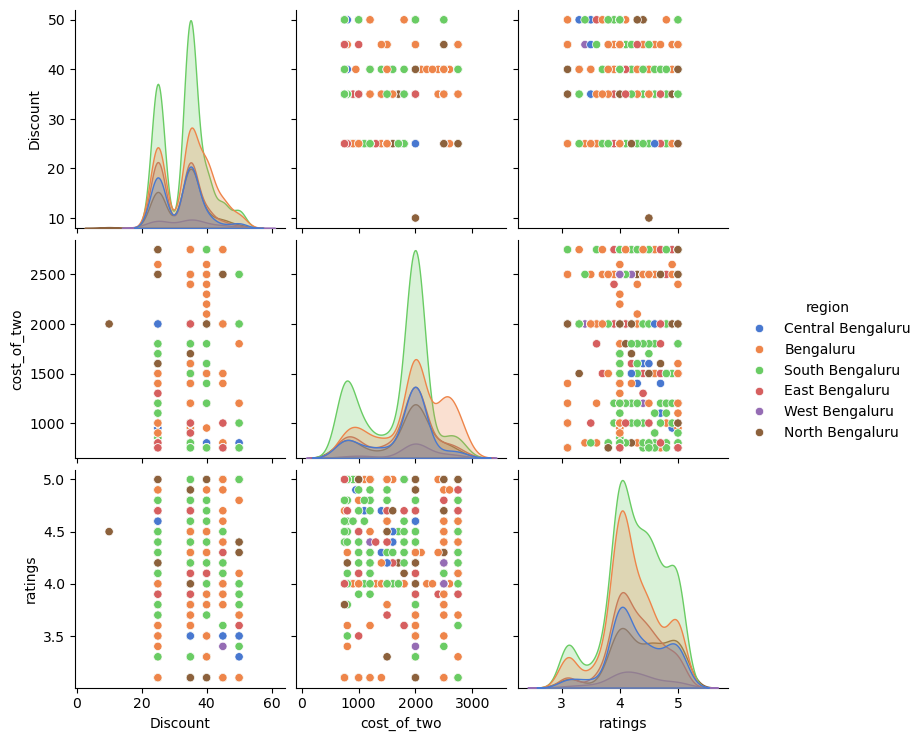

In [64]:
sns.pairplot( df, vars=num_cols, hue="region", palette="muted")
plt.show()

### Observations :
- The pair plot shows the distribution and relationships among the numerical features across different regions.
- Most regions have overlapping data points, indicating similar patterns in ratings, discounts, and cost.
- Overall, no strong relationship or clear regional clustering is observed among the numerical variables.

# Cost, Rating and Region

<Axes: xlabel='cost_of_two', ylabel='ratings'>

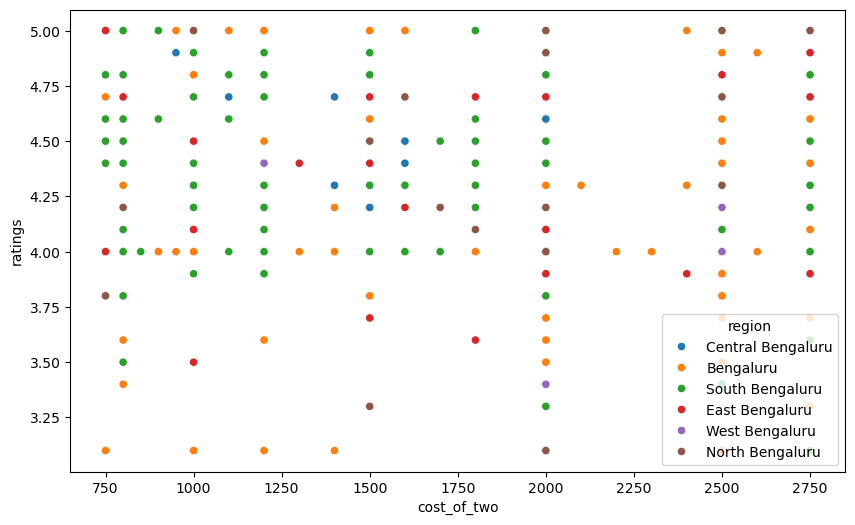

In [77]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x="cost_of_two", y="ratings", hue="region")

### Observations :
- The scatter plot shows that restaurants across different price ranges receive similar ratings, regardless of their region.
- There is no strong relationship between the cost for two and restaurant ratings, as highly rated restaurants exist at both low and high price points.
- Overall, restaurant quality is not solely determined by price, and regional patterns largely overlap.